In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

df = pd.DataFrame(load_breast_cancer().data, columns=load_breast_cancer().feature_names)
df['target'] = load_breast_cancer().target
df.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0


In [4]:
# k fold
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC

X = df[df.columns[:-1]]
y = df[df.columns[-1]]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = SVC(C=1.0, kernel='linear')
scores = cross_val_score(model, X, y, cv=kf)
scores

array([0.95614035, 0.94736842, 0.95614035, 0.97368421, 0.92920354])

In [5]:
scores.mean()

np.float64(0.9525073746312686)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df[df.columns[:-1]], df[df.columns[-1]], random_state=42)
model = SVC(C=1.0, kernel='linear').fit(X_train, y_train)
scores = cross_val_score(model, X, y, cv=5)
scores, np.mean(scores)

(array([0.94736842, 0.92982456, 0.97368421, 0.92105263, 0.95575221]),
 np.float64(0.9455364073901569))

In [7]:
def plot_cross_validation(train_scores, test_scores, param_range):
    plt.figure()

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title('Validation Curve with SVM')
    plt.xlabel('$\gamma$ (gamma)')
    plt.ylabel('Score')
    plt.ylim(0.0, 1.1)
    lw = 2

    plt.semilogx(param_range, train_scores_mean, label='Training score',
                color='darkorange', lw=lw)

    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.2,
                    color='darkorange', lw=lw)

    plt.semilogx(param_range, test_scores_mean, label='Cross-validation score',
                color='navy', lw=lw)

    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.2,
                    color='navy', lw=lw)

    plt.legend(loc='best')
    plt.show()

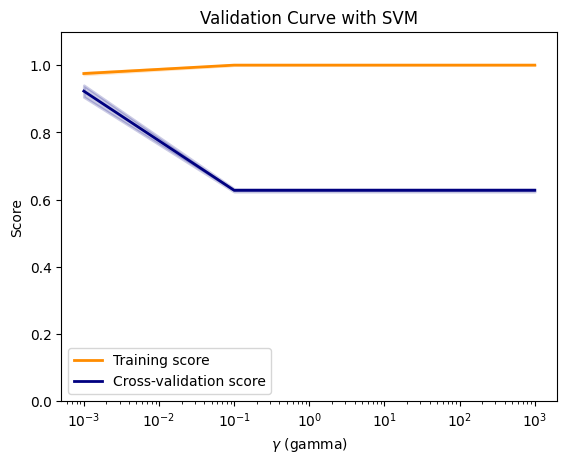

(array([[0.97362637, 0.97802198, 0.97362637, 0.97802198, 0.97149123],
        [1.        , 1.        , 1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        , 1.        , 1.        ]]),
 array([[0.92982456, 0.92105263, 0.92105263, 0.94736842, 0.89380531],
        [0.62280702, 0.62280702, 0.63157895, 0.63157895, 0.62831858],
        [0.62280702, 0.62280702, 0.63157895, 0.63157895, 0.62831858],
        [0.62280702, 0.62280702, 0.63157895, 0.63157895, 0.62831858]]))

In [8]:
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3, 3, 4)
train_scores, test_scores = validation_curve(SVC(), X, y, param_name='gamma', param_range=param_range, cv=5)
plot_cross_validation(train_scores, test_scores, param_range)
train_scores, test_scores